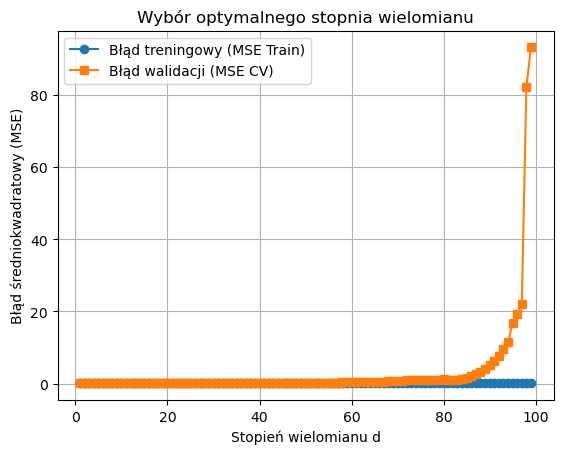

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error


n = 200
x = np.random.uniform(0, 1, n)
epsilon = np.random.normal(0, 0.3, n)
y = np.sin(2 * np.pi * x) + epsilon

X = x.reshape(-1, 1)

d = range(1, 100)
mse_cv = []
mse_train=[]
for i in d:
    model = make_pipeline(PolynomialFeatures(i), LinearRegression())
    model.fit(X,y)
    y_pred=model.predict(X)
    mse=mean_squared_error(y,y_pred)
    mse_train.append(mse)
    
    wynik_cv = np.mean(cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')) * (-1)
    mse_cv.append(wynik_cv)

plt.plot(d, mse_train, marker='o', label='Błąd treningowy (MSE Train)')
plt.plot(d, mse_cv, marker='s', label='Błąd walidacji (MSE CV)')
plt.xlabel('Stopień wielomianu d')
plt.ylabel('Błąd średniokwadratowy (MSE)')
plt.title('Wybór optymalnego stopnia wielomianu')
plt.legend()
plt.grid(True)
plt.show()

    